In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

df = pd.read_csv("insurance.csv")
print("Shape:", df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
numerical_cols = ['age', 'bmi', 'children', 'charges']
categorical_cols = ['sex', 'smoker', 'region']

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)
print("\nBefore any encoding/scaling:")
df.dtypes

Numerical Columns: ['age', 'bmi', 'children', 'charges']
Categorical Columns: ['sex', 'smoker', 'region']

Before any encoding/scaling:


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [4]:
scaler_standard = StandardScaler()

df_standard = df.copy()
df_standard[numerical_cols] = scaler_standard.fit_transform(df[numerical_cols])

print("After Standard Scaling (mean=0, std=1):")
df_standard[numerical_cols].describe().round(2)

After Standard Scaling (mean=0, std=1):


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.51,-2.41,-0.91,-1.00
25%,-0.87,-0.72,-0.91,-0.70
50%,-0.01,-0.04,-0.08,-0.32
75%,0.84,0.66,0.75,0.28
max,1.77,3.69,3.24,4.17


In [5]:
scaler_minmax = MinMaxScaler()

df_minmax = df.copy()
df_minmax[numerical_cols] = scaler_minmax.fit_transform(df[numerical_cols])

print("After Min-Max Scaling (values between 0 and 1):")
df_minmax[numerical_cols].describe().round(2)

After Min-Max Scaling (values between 0 and 1):


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,0.46,0.40,0.22,0.19
std,0.31,0.16,0.24,0.19
min,0.00,0.00,0.00,0.00
25%,0.20,0.28,0.00,0.06
50%,0.46,0.39,0.20,0.13
75%,0.72,0.50,0.40,0.25
max,1.00,1.00,1.00,1.00


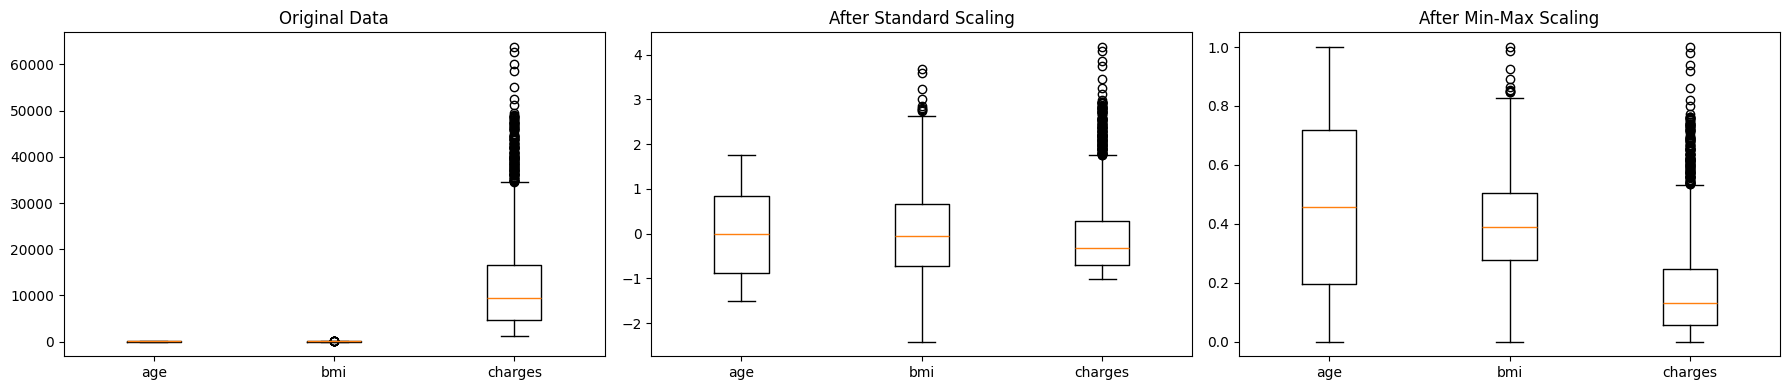

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Original
axes[0].boxplot([df['age'], df['bmi'], df['charges']], tick_labels=['age', 'bmi', 'charges'])
axes[0].set_title('Original Data')

# Standard Scaled
axes[1].boxplot([df_standard['age'], df_standard['bmi'], df_standard['charges']], tick_labels=['age', 'bmi', 'charges'])
axes[1].set_title('After Standard Scaling')

# Min-Max Scaled
axes[2].boxplot([df_minmax['age'], df_minmax['bmi'], df_minmax['charges']], tick_labels=['age', 'bmi', 'charges'])
axes[2].set_title('After Min-Max Scaling')

plt.tight_layout()
plt.show()

In [8]:
df_encoded = df.copy()

# Apply one hot encoding to categorical columns
df_encoded = pd.get_dummies(df_encoded, columns=['sex', 'smoker', 'region'], drop_first=False)

print("Shape before encoding:", df.shape)
print("Shape after encoding :", df_encoded.shape)
print("\nNew columns added:", [col for col in df_encoded.columns if col not in df.columns])
df_encoded.head()

Shape before encoding: (1338, 7)
Shape after encoding : (1338, 12)

New columns added: ['sex_female', 'sex_male', 'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


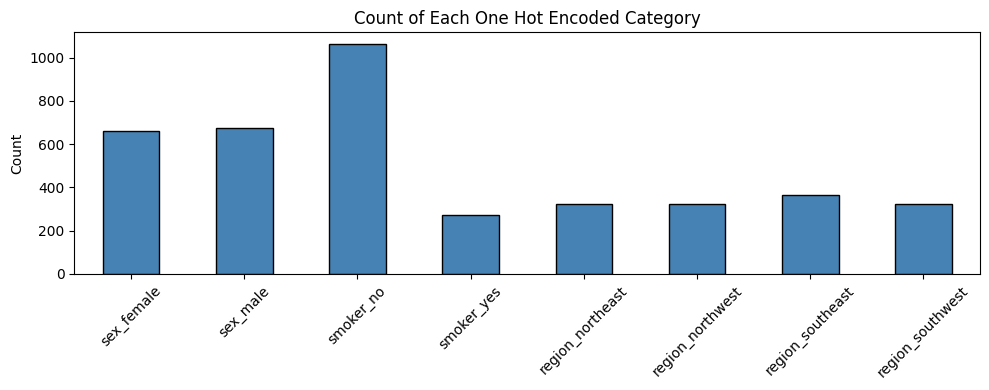

In [9]:
encoded_cols = [col for col in df_encoded.columns if col not in ['age', 'bmi', 'children', 'charges']]

df_encoded[encoded_cols].sum().plot(kind='bar', figsize=(10, 4), color='steelblue', edgecolor='black')
plt.title('Count of Each One Hot Encoded Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
df_final = df_encoded.copy()

# Apply standard scaling to numerical columns
df_final[numerical_cols] = scaler_standard.fit_transform(df_final[numerical_cols])

print("Final Preprocessed Dataset Shape:", df_final.shape)
print("\nSample of final dataset:")
df_final.head()

Final Preprocessed Dataset Shape: (1338, 12)

Sample of final dataset:


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,0.298584,True,False,False,True,False,False,False,True
1,-1.509965,0.509621,-0.078767,-0.953689,False,True,True,False,False,False,True,False
2,-0.797954,0.383307,1.580926,-0.728675,False,True,True,False,False,False,True,False
3,-0.441948,-1.305531,-0.908614,0.719843,False,True,True,False,False,True,False,False
4,-0.513149,-0.292556,-0.908614,-0.776802,False,True,True,False,False,True,False,False


In [11]:
df_final.to_csv("insurance_preprocessed.csv", index=False)
print("Final preprocessed dataset exported as 'insurance_preprocessed.csv'")

Final preprocessed dataset exported as 'insurance_preprocessed.csv'
